# Fig Floruit Distribution


In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Age at floruit (P1317)

For individuals with **both** a floruit (P1317) and a birthdate (P569), we compute `age_at_floruit = floruit_year - birth_year`. This tells us at what age people tend to be considered "flourishing" — the empirical prior we need to infer floruit when only birth + region are known.

In [2]:
import re
import duckdb
import polars as pl
import pandas as pd  # kept only for tiny in-memory tables built from API responses
import matplotlib.pyplot as plt

DB = DB_PATH

BIN_WIDTH = 500
YEAR_MIN, YEAR_MAX = -3000, 2500
AGE_MIN, AGE_MAX  = 10, 100   # plausibility filter for human flourishing age

def bin_start(year, w=BIN_WIDTH):
    return int(np.floor(year / w) * w)

bin_edges = list(range(YEAR_MIN, YEAR_MAX + 1, BIN_WIDTH))

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
    'font.size': 9,
})


### 1. Load floruit + birth

In [3]:
conn = duckdb.connect(DB, read_only=True)
Q_AGE = """
SELECT f.wikidata_id,
       f.floruit_year,
       f.floruit_precision,
       i.birthdate,
       i.deathdate
FROM individuals_floruit_period f
JOIN individuals i ON i.wikidata_id = f.wikidata_id
WHERE f.floruit_year IS NOT NULL
  AND i.birthdate IS NOT NULL
  AND f.floruit_precision >= 9   -- year (9), month (10), day (11) only; drop decade (8), century (7), etc.
"""
raw = conn.execute(Q_AGE).pl()
conn.close()

def signed_year(s):
    if not isinstance(s, str): return None
    m = re.match(r'^(-?)(\d+)', s.strip())
    if not m: return None
    y = int(m.group(2))
    return -y if m.group(1) == '-' else y

raw = (
    raw.with_columns(
        pl.col('birthdate').map_elements(signed_year, return_dtype=pl.Int64).alias('birth_year')
    )
    .drop_nulls(subset=['birth_year'])
    .with_columns(
        pl.col('birth_year').cast(pl.Int64),
        pl.col('floruit_year').cast(pl.Int64),
    )
    .with_columns(
        (pl.col('floruit_year') - pl.col('birth_year')).alias('age_at_floruit')
    )
)

plausible = raw.filter(
    (pl.col('age_at_floruit') >= AGE_MIN) & (pl.col('age_at_floruit') <= AGE_MAX)
)

n_low  = raw.filter(pl.col('age_at_floruit') < AGE_MIN).height
n_high = raw.filter(pl.col('age_at_floruit') > AGE_MAX).height

print(f'Pairs with floruit (year-precision) & birthdate: {raw.height:,}')
print(f'  age in [{AGE_MIN},{AGE_MAX}]:                 {plausible.height:,}')
print(f'  age < {AGE_MIN}:                              {n_low:,}')
print(f'  age > {AGE_MAX}:                              {n_high:,}')
print()
print('Floruit precision distribution (kept rows):')
print(raw.group_by('floruit_precision').agg(pl.len().alias('count')).sort('floruit_precision'))
print()
print('Summary (plausible subset):')
print(plausible.select('age_at_floruit').describe())

Pairs with floruit (year-precision) & birthdate: 18,334
  age in [10,100]:                 17,042
  age < 10:                              1,048
  age > 100:                              244

Floruit precision distribution (kept rows):
shape: (3, 2)
┌───────────────────┬───────┐
│ floruit_precision ┆ count │
│ ---               ┆ ---   │
│ i64               ┆ u32   │
╞═══════════════════╪═══════╡
│ 9                 ┆ 18014 │
│ 10                ┆ 97    │
│ 11                ┆ 223   │
└───────────────────┴───────┘

Summary (plausible subset):
shape: (9, 2)
┌────────────┬────────────────┐
│ statistic  ┆ age_at_floruit │
│ ---        ┆ ---            │
│ str        ┆ f64            │
╞════════════╪════════════════╡
│ count      ┆ 17042.0        │
│ null_count ┆ 0.0            │
│ mean       ┆ 42.722626      │
│ std        ┆ 17.814993      │
│ min        ┆ 10.0           │
│ 25%        ┆ 29.0           │
│ 50%        ┆ 40.0           │
│ 75%        ┆ 54.0           │
│ max        ┆ 100.0 

### 2.1 Age distribution curves by historical era

One curve per era (KDE of age at floruit), so you can see whether the *typical* flourishing age shifts between Antiquity, the Middle Ages, the Early Modern period, the 19th century and the 20th–21st centuries.

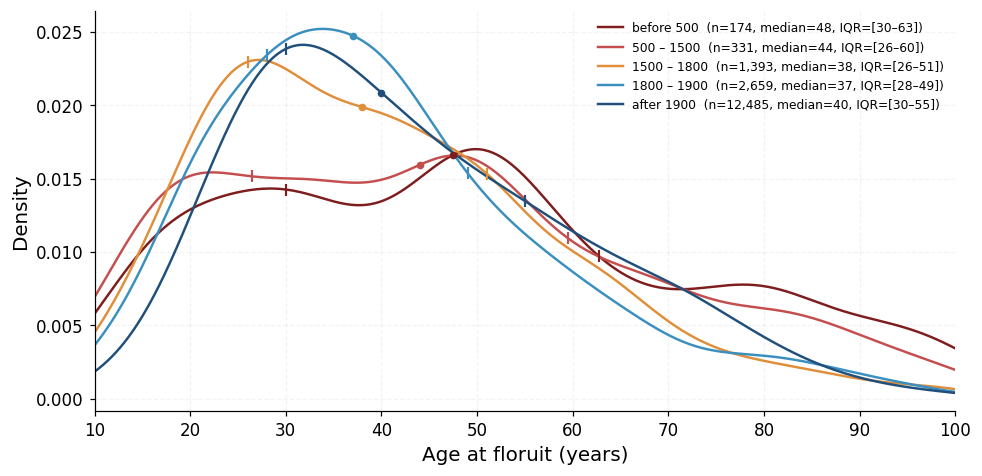

In [4]:
from scipy.stats import gaussian_kde

eras = [
    ('before 500',     None,  500),
    ('500 – 1500',      500, 1500),
    ('1500 – 1800',    1500, 1800),
    ('1800 – 1900',    1800, 1900),
    ('after 1900',     1900, None),
]

palette = ['#7e1d1d', '#c44e4e', '#e08e3a', '#3a8fbf', '#1f4f7a']

x_grid = np.linspace(AGE_MIN, AGE_MAX, 400)

fig, ax = plt.subplots(figsize=(9, 4.4))

for (label, lo, hi), color in zip(eras, palette):
    mask = pl.lit(True)
    if lo is not None:
        mask = mask & (pl.col('floruit_year') >= lo)
    if hi is not None:
        mask = mask & (pl.col('floruit_year') < hi)
    sub = plausible.filter(mask)['age_at_floruit'].to_numpy()
    if len(sub) < 5:
        continue
    kde = gaussian_kde(sub, bw_method=0.25)
    y = kde(x_grid)
    med = float(np.median(sub))
    q25 = float(np.quantile(sub, 0.25))
    q75 = float(np.quantile(sub, 0.75))
    ax.plot(x_grid, y, color=color, linewidth=1.6,
            label=f'{label}  (n={len(sub):,}, median={med:.0f}, IQR=[{q25:.0f}–{q75:.0f}])')
    # mark median
    ax.plot([med], [kde(med)[0]], 'o', color=color, markersize=4, zorder=3)
    # mark q25 / q75
    ax.plot([q25, q75], [kde(q25)[0], kde(q75)[0]], '|',
            color=color, markersize=8, markeredgewidth=1.4, zorder=3)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### 2.1b Age distribution curves by cross-verified occupation

Same KDE methodology as §2.1, but stratified by the top-level occupational category from Laouenan et al. (2022) — `level1_main_occ` ∈ {*Culture*, *Discovery/Science*, *Leadership*, *Sports/Games*}; *Missing* and *Other* dropped. Restricted to the year-precision floruit pairs already filtered (`plausible`) joined to the cross-verified database on `wikidata_id`.

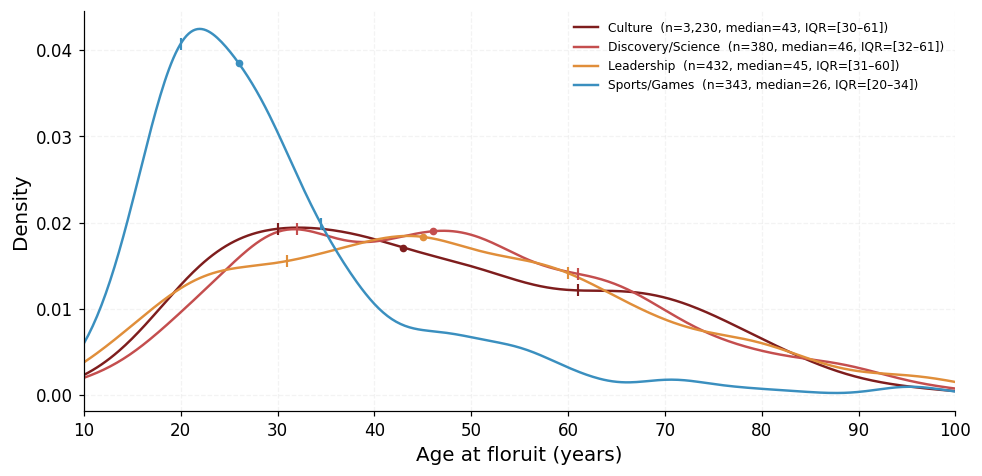

In [5]:
from pathlib import Path
from scipy.stats import gaussian_kde

CV_PATH = Path('..') / 'data' / 'similar_databases' / 'cross-verified-database' / 'cross-verified-database.utf8.csv.gz'

cv_occ = (
    pl.read_csv(
        CV_PATH,
        columns=['wikidata_code', 'level1_main_occ'],
        schema_overrides={'wikidata_code': pl.Utf8, 'level1_main_occ': pl.Utf8},
    )
    .drop_nulls(['wikidata_code', 'level1_main_occ'])
    .rename({'wikidata_code': 'wikidata_id'})
)

plausible_occ = plausible.join(cv_occ, on='wikidata_id', how='inner')

occupations = ['Culture', 'Discovery/Science', 'Leadership', 'Sports/Games']

palette = ['#7e1d1d', '#c44e4e', '#e08e3a', '#3a8fbf']

x_grid = np.linspace(AGE_MIN, AGE_MAX, 400)

fig, ax = plt.subplots(figsize=(9, 4.4))

for label, color in zip(occupations, palette):
    sub = plausible_occ.filter(pl.col('level1_main_occ') == label)['age_at_floruit'].to_numpy()
    if len(sub) < 5:
        continue
    kde = gaussian_kde(sub, bw_method=0.25)
    y = kde(x_grid)
    med = float(np.median(sub))
    q25 = float(np.quantile(sub, 0.25))
    q75 = float(np.quantile(sub, 0.75))
    ax.plot(x_grid, y, color=color, linewidth=1.6,
            label=f'{label}  (n={len(sub):,}, median={med:.0f}, IQR=[{q25:.0f}–{q75:.0f}])')
    # mark median
    ax.plot([med], [kde(med)[0]], 'o', color=color, markersize=4, zorder=3)
    # mark q25 / q75
    ax.plot([q25, q75], [kde(q25)[0], kde(q75)[0]], '|',
            color=color, markersize=8, markeredgewidth=1.4, zorder=3)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### 2.2 Evolution across centuries

Median `age_at_floruit` per 100-year bin of `floruit_year`, with a shaded interquartile band (Q1 → Q3) tracing the spread around the median over time. Centuries with fewer than 30 individuals are dropped.

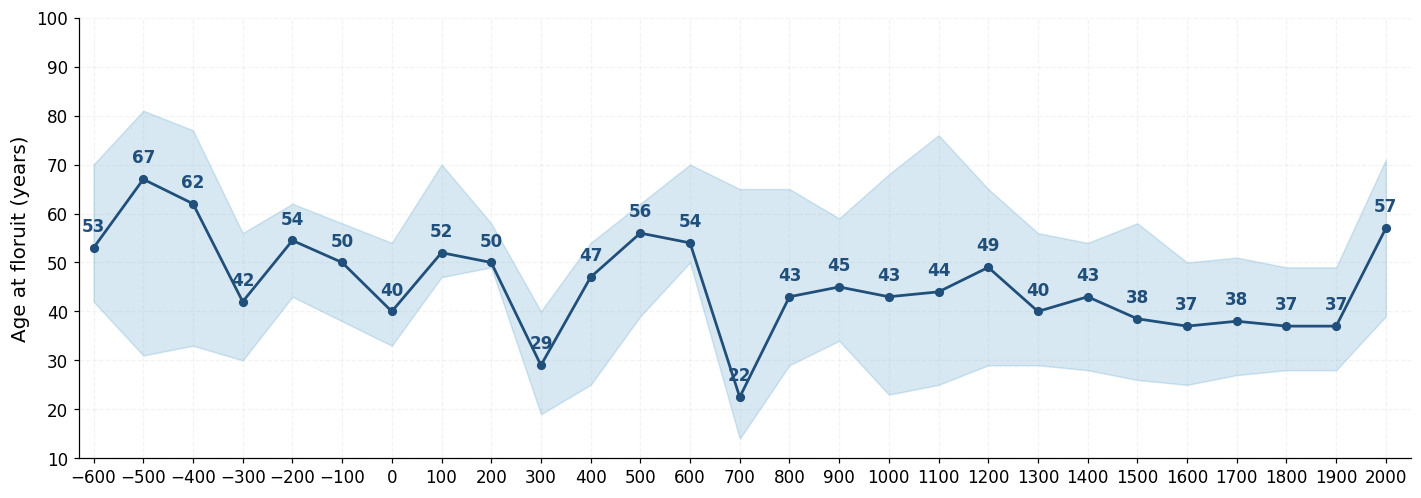

Bins plotted: 27  (min n = 5)
shape: (27, 5)
┌──────┬──────┬────────┬──────┬──────┐
│ bin  ┆ n    ┆ median ┆ q25  ┆ q75  │
│ ---  ┆ ---  ┆ ---    ┆ ---  ┆ ---  │
│ i64  ┆ u32  ┆ f64    ┆ f64  ┆ f64  │
╞══════╪══════╪════════╪══════╪══════╡
│ -600 ┆ 12   ┆ 53.0   ┆ 42.0 ┆ 70.0 │
│ -500 ┆ 16   ┆ 67.0   ┆ 31.0 ┆ 81.0 │
│ -400 ┆ 21   ┆ 62.0   ┆ 33.0 ┆ 77.0 │
│ -300 ┆ 15   ┆ 42.0   ┆ 30.0 ┆ 56.0 │
│ -200 ┆ 16   ┆ 54.5   ┆ 43.0 ┆ 62.0 │
│ …    ┆ …    ┆ …      ┆ …    ┆ …    │
│ 1600 ┆ 504  ┆ 37.0   ┆ 25.0 ┆ 50.0 │
│ 1700 ┆ 657  ┆ 38.0   ┆ 27.0 ┆ 51.0 │
│ 1800 ┆ 2659 ┆ 37.0   ┆ 28.0 ┆ 49.0 │
│ 1900 ┆ 9586 ┆ 37.0   ┆ 28.0 ┆ 49.0 │
│ 2000 ┆ 2899 ┆ 57.0   ┆ 39.0 ┆ 71.0 │
└──────┴──────┴────────┴──────┴──────┘


In [6]:
MIN_N_BIN     = 5
MAX_EARLY_GAP = 10_000   # effectively disable trim — show the past
LAST_X        = 2000


def evolution_bins(df, bin_width=100, value_col='age_at_floruit',
                   min_n=MIN_N_BIN, max_early_gap=MAX_EARLY_GAP):
    """Bin `floruit_year`, keep bins with ≥ `min_n`, then drop every bin
    before the latest gap > `max_early_gap` years.
    """
    bins_df = (
        df.with_columns(
            ((pl.col('floruit_year') // bin_width) * bin_width)
            .cast(pl.Int64).alias('bin')
        )
        .group_by('bin')
        .agg(pl.len().alias('n'),
             pl.col(value_col).median().alias('median'),
             pl.col(value_col).quantile(0.25).alias('q25'),
             pl.col(value_col).quantile(0.75).alias('q75'))
        .filter(pl.col('n') >= min_n)
        .sort('bin')
    )
    if bins_df.height <= 1:
        return bins_df
    bins = bins_df['bin'].to_list()
    start_idx = 0
    for i in range(len(bins) - 1, 0, -1):
        if bins[i] - bins[i - 1] > max_early_gap:
            start_idx = i
            break
    return bins_df.slice(start_idx)


bw_global = 100
cs_global = evolution_bins(plausible, bin_width=bw_global)

xs  = cs_global['bin'].to_numpy().astype(float)
med = cs_global['median'].to_numpy()
q25 = cs_global['q25'].to_numpy()
q75 = cs_global['q75'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.fill_between(xs, q25, q75, color='#3a8fbf', alpha=0.20)
ax.plot(xs, med, color='#1f4f7a', linewidth=1.8,
        marker='o', markersize=5)
for x, m in zip(xs, med):
    ax.annotate(f'{m:.0f}', (x, m), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, color='#1f4f7a',
                fontweight='bold')

x_left = float(cs_global['bin'][0])
ax.set_xlim(x_left - bw_global * 0.3, LAST_X + bw_global / 2)
ax.set_xticks(list(range(int(x_left), LAST_X + 1, bw_global)))
ax.set_ylim(AGE_MIN, AGE_MAX)
ax.set_ylabel('Age at floruit (years)')
plt.tight_layout()
plt.show()

print(f'Bins plotted: {cs_global.height}  (min n = {MIN_N_BIN})')
print(cs_global)

### 2.3 Evolution across centuries — by cross-verified occupation

Same 100-year-bin median + IQR shaded band as §2.2, but split by the four main CV occupations. Centuries with fewer than 30 individuals **in that category** are dropped.

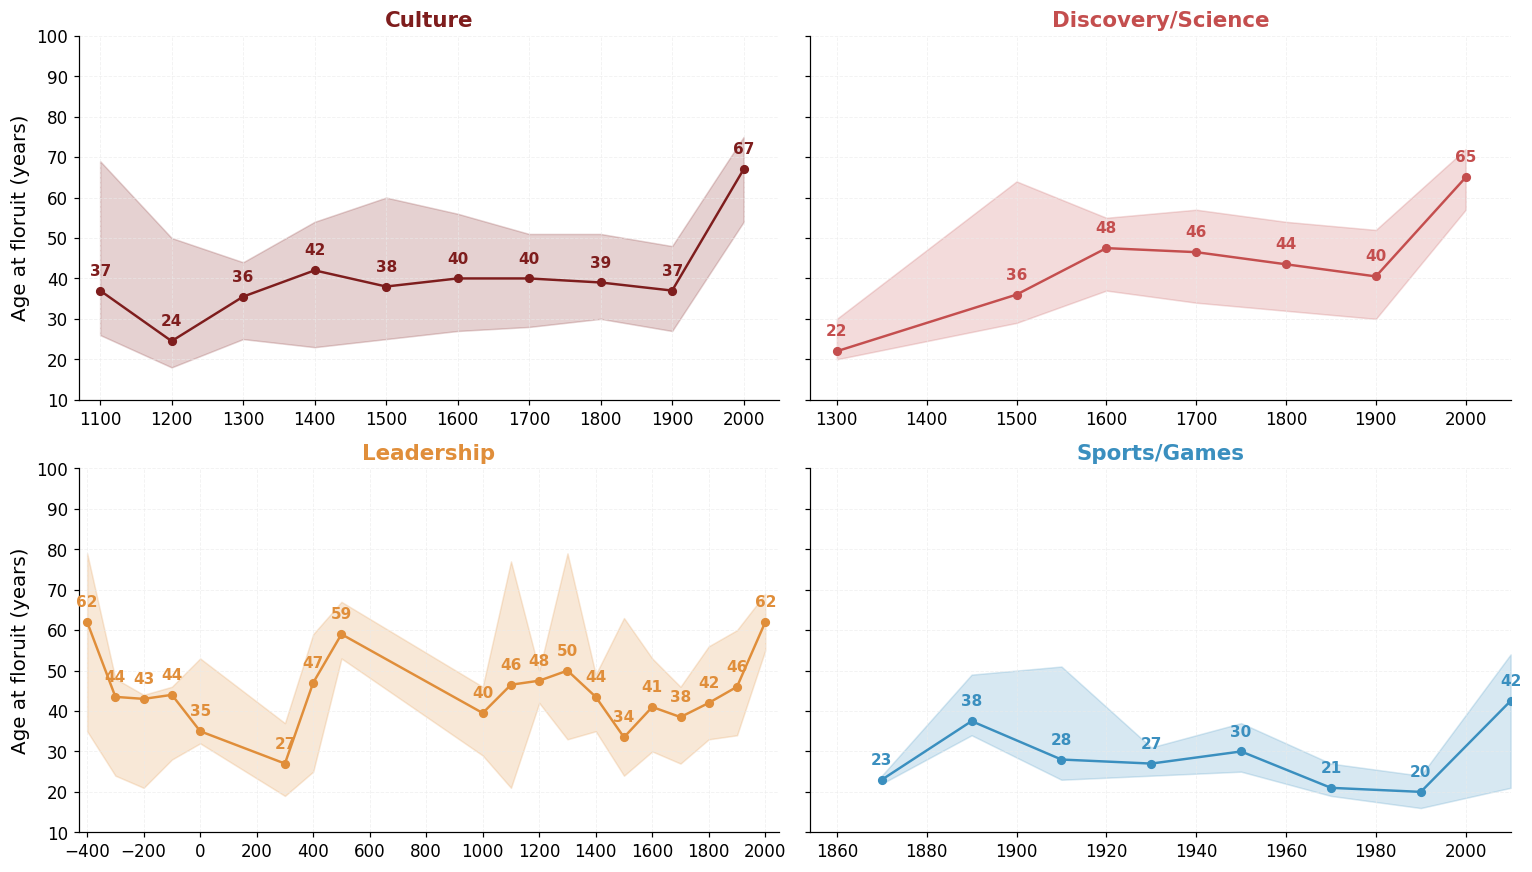

Rows plotted across panels: 44  (min n = 5)
shape: (44, 6)
┌──────────────┬──────┬─────┬────────┬──────┬──────┐
│ occupation   ┆ bin  ┆ n   ┆ median ┆ q25  ┆ q75  │
│ ---          ┆ ---  ┆ --- ┆ ---    ┆ ---  ┆ ---  │
│ str          ┆ i64  ┆ u32 ┆ f64    ┆ f64  ┆ f64  │
╞══════════════╪══════╪═════╪════════╪══════╪══════╡
│ Culture      ┆ 1100 ┆ 6   ┆ 37.0   ┆ 26.0 ┆ 69.0 │
│ Culture      ┆ 1200 ┆ 6   ┆ 24.5   ┆ 18.0 ┆ 50.0 │
│ Culture      ┆ 1300 ┆ 18  ┆ 35.5   ┆ 25.0 ┆ 44.0 │
│ Culture      ┆ 1400 ┆ 49  ┆ 42.0   ┆ 23.0 ┆ 54.0 │
│ Culture      ┆ 1500 ┆ 75  ┆ 38.0   ┆ 25.0 ┆ 60.0 │
│ …            ┆ …    ┆ …   ┆ …      ┆ …    ┆ …    │
│ Sports/Games ┆ 1920 ┆ 84  ┆ 27.0   ┆ 24.0 ┆ 31.0 │
│ Sports/Games ┆ 1940 ┆ 73  ┆ 30.0   ┆ 25.0 ┆ 37.0 │
│ Sports/Games ┆ 1960 ┆ 56  ┆ 21.0   ┆ 19.0 ┆ 27.0 │
│ Sports/Games ┆ 1980 ┆ 63  ┆ 20.0   ┆ 16.0 ┆ 24.0 │
│ Sports/Games ┆ 2000 ┆ 18  ┆ 42.5   ┆ 21.0 ┆ 54.0 │
└──────────────┴──────┴─────┴────────┴──────┴──────┘


In [7]:
cat_palette = dict(zip(occupations, palette))

panel_bw = {
    'Culture':           100,
    'Discovery/Science': 100,
    'Leadership':        100,
    'Sports/Games':       20,
}

panel_min_year = {
    'Culture':           1100,
    'Discovery/Science': 1300,
    'Leadership':        None,
    'Sports/Games':      None,
}

MAX_TICKS = 14   # auto-thin tick labels above this

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes_flat = axes.flatten()

per_cat_summary = []

for ax, cat in zip(axes_flat, occupations):
    color = cat_palette[cat]
    bw    = panel_bw[cat]
    sub_df = plausible_occ.filter(pl.col('level1_main_occ') == cat)
    cs = evolution_bins(sub_df, bin_width=bw)

    min_year = panel_min_year[cat]
    if min_year is not None:
        cs = cs.filter(pl.col('bin') >= min_year)

    if cs.height == 0:
        ax.set_title(cat, fontsize=14, color=color, fontweight='bold')
        continue

    xs = cs['bin'].to_numpy().astype(float)
    if bw != 100:
        xs = xs + bw / 2

    med = cs['median'].to_numpy()
    q25 = cs['q25'].to_numpy()
    q75 = cs['q75'].to_numpy()

    ax.fill_between(xs, q25, q75, color=color, alpha=0.20)
    ax.plot(xs, med, color=color, linewidth=1.6,
            marker='o', markersize=5)
    for x, m in zip(xs, med):
        ax.annotate(f'{m:.0f}', (x, m),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, color=color,
                    fontweight='bold')

    x_left   = float(cs['bin'][0])
    left_pad = bw * 0.3
    ax.set_xlim(x_left - left_pad, LAST_X + bw / 2)

    # Tick density: start with one tick per bin, decimate if too crowded.
    ticks = list(range(int(x_left), LAST_X + 1, bw))
    while len(ticks) > MAX_TICKS:
        ticks = ticks[::2]
    ax.set_xticks(ticks)

    ax.set_ylim(AGE_MIN, AGE_MAX)
    ax.set_title(cat, fontsize=14, color=color, fontweight='bold')
    ax.grid(True, color='#eaeaea', linewidth=0.6, alpha=0.6)

    per_cat_summary.append(cs.with_columns(pl.lit(cat).alias('occupation')))

for ax in axes[:, 0]:
    ax.set_ylabel('Age at floruit (years)')

plt.tight_layout()
plt.show()

if per_cat_summary:
    summary = pl.concat(per_cat_summary).select(
        ['occupation', 'bin', 'n', 'median', 'q25', 'q75']
    )
    print(f'Rows plotted across panels: {summary.height}  (min n = {MIN_N_BIN})')
    print(summary)